# Cross-Validation

Evaluate model generalization via 80/20 train/test cross-validation
across the fusion-regularization grid.

**Outline**
1. Load simulated functional scores and pipeline config
2. Split data into train (80%) and test (20%) sets, stratifying WT variants
3. Fit models on training data across the fusionreg grid
4. Evaluate validation loss on held-out test data
5. Visualize training vs validation loss across regularization strengths


In [1]:
import warnings

warnings.filterwarnings("ignore")

import os
import sys

sys.path.insert(0, "notebooks")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import multidms
from multidms.model_collection import ModelCollection, fit_models
from multidms.utils import explode_params_dict

from _common import load_config, build_fit_params, all_muts_known


In [2]:
config_path = "config/config.yaml" 


In [3]:
# Parameters
config_path = "config/config.yaml"


In [4]:
config = load_config(config_path)
sim = config["simulation"]
fit_config = sim["fitting"]

seed = config["seed"]
train_frac = config["train_frac"]
output_dir = sim["output_dir"]
lasso_choice = sim["lasso_choice"]

os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")


Output directory: results


## Load functional scores


In [5]:
func_scores = pd.read_csv(os.path.join(output_dir, "simulated_func_scores.csv"))
func_scores["func_score_type"] = pd.Categorical(
    func_scores["func_score_type"],
    categories=["observed_phenotype", "loose_bottle", "tight_bottle"],
    ordered=True,
)
print(f"Loaded {len(func_scores)} rows")


Loaded 349866 rows


## Train/test split

Split functional scores into 80% train / 20% test.
All wildtype variants are kept in the training set (stratified split).


In [6]:
train_datasets = []
test_data = {}

for (library, measurement), fs_df in func_scores.rename(
    columns={"homolog": "condition"}
).groupby(["library", "func_score_type"]):
    if "enrichment" in str(measurement):
        continue

    wt_mask = fs_df["aa_substitutions"].fillna("").str.strip() == ""
    wt_rows = fs_df[wt_mask]
    non_wt_rows = fs_df[~wt_mask].sample(frac=1, random_state=seed)

    n_train = int(len(non_wt_rows) * train_frac)
    train_split = pd.concat([wt_rows, non_wt_rows.iloc[:n_train]])
    test_split = non_wt_rows.iloc[n_train:]

    name = f"{library}_{measurement}"

    train_split = train_split.copy()
    train_split["aa_substitutions"] = train_split[
        "aa_substitutions"
    ].fillna("")

    train_datasets.append(
        multidms.Data(
            train_split,
            reference="h1",
            alphabet=multidms.AAS_WITHSTOP_WITHGAP,
            verbose=False,
            name=name,
        )
    )
    test_data[name] = test_split

print(
    f"Created {len(train_datasets)} train datasets, "
    f"{len(test_data)} test datasets"
)


Created 6 train datasets, 6 test datasets


## Fit models on training data


In [7]:
cv_fitting_params = build_fit_params(fit_config, train_datasets)

# Determine n_processes for parallel fitting
n_models = len(explode_params_dict(cv_fitting_params))
cfg_n_processes = fit_config.get("n_processes")

if cfg_n_processes is None:
    n_processes = min(os.cpu_count() // 2, n_models)
else:
    n_processes = min(int(cfg_n_processes), n_models)

n_processes = max(n_processes, 1)
print(f"Fitting {n_models} CV models with n_processes={n_processes} (cpus={os.cpu_count()})")

n_fit_cv, n_failed_cv, fit_collection_cv = fit_models(
    cv_fitting_params, n_processes=n_processes
)

# Convert dict-valued columns to strings for groupby compatibility
for col in fit_collection_cv.columns:
    if fit_collection_cv[col].apply(lambda x: isinstance(x, dict)).any():
        fit_collection_cv[col] = fit_collection_cv[col].apply(str)

print(f"CV: fit {n_fit_cv} models, {n_failed_cv} failed")


Fitting 42 CV models with n_processes=16 (cpus=32)


CV: fit 42 models, 0 failed


## Evaluate validation loss

Filter test variants to exclude those with mutations unseen during training,
then compute validation loss via `add_eval_loss`.


In [8]:
mc_cv = ModelCollection(fit_collection_cv)

filtered_test = {}
for name, test_df in test_data.items():
    model = (
        mc_cv.fit_models.query(f"dataset_name == '{name}'")
        .iloc[0]
        .model
    )
    known_muts = set(model.data.mutations)

    mask = test_df["aa_substitutions"].apply(
        lambda s: all_muts_known(s, known_muts)
    )
    filtered_test[name] = test_df[mask]
    n_dropped = (~mask).sum()
    if n_dropped > 0:
        print(
            f"{name}: dropped {n_dropped}/{len(test_df)} "
            "test variants with unseen mutations"
        )

mc_cv.add_eval_loss(filtered_test, overwrite=True)


lib_1_observed_phenotype: dropped 2734/11696 test variants with unseen mutations
lib_1_loose_bottle: dropped 2711/11696 test variants with unseen mutations
lib_1_tight_bottle: dropped 2711/11696 test variants with unseen mutations
lib_2_observed_phenotype: dropped 2667/11628 test variants with unseen mutations


lib_2_loose_bottle: dropped 2767/11628 test variants with unseen mutations
lib_2_tight_bottle: dropped 2767/11628 test variants with unseen mutations


## Visualize cross-validation loss

Training vs validation loss (mean Huber loss per variant) across
the fusion-regularization grid, faceted by measurement type.


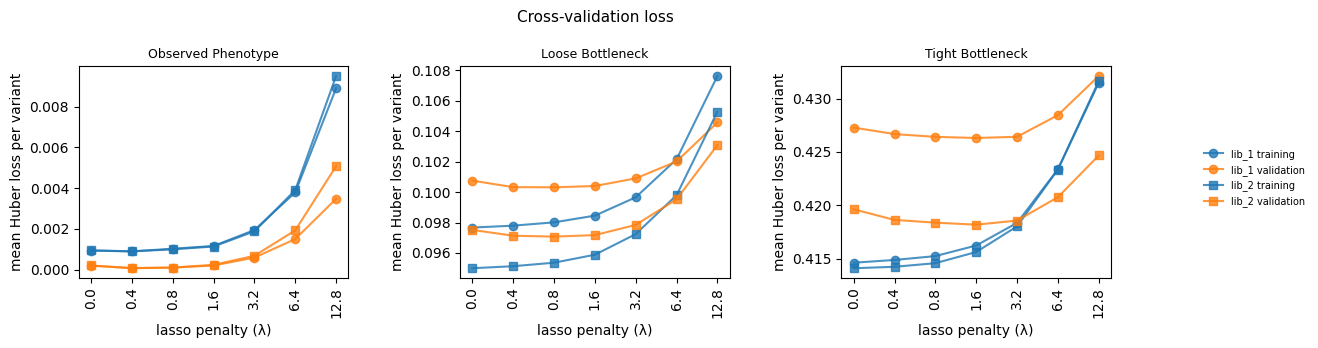

In [9]:
NICE_TITLES = {
    "observed_phenotype": "Observed Phenotype",
    "loose_bottle": "Loose Bottleneck",
    "tight_bottle": "Tight Bottleneck",
}
MT_ORDER = ["observed_phenotype", "loose_bottle", "tight_bottle"]

cv_data = mc_cv.fit_models.copy()
cv_data["library"] = (
    cv_data["dataset_name"].str.split("_").str[0:2].str.join("_")
)
cv_data["measurement_type"] = (
    cv_data["dataset_name"].str.split("_").str[2:4].str.join("_")
)
cv_data["measurement_type"] = pd.Categorical(
    cv_data["measurement_type"],
    categories=["observed_phenotype", "loose_bottle", "tight_bottle"],
    ordered=True,
)

cv_data = (
    cv_data.melt(
        id_vars=[
            "fusionreg",
            "library",
            "measurement_type",
            "dataset_name",
        ],
        value_vars=["total_loss_training", "total_loss_validation"],
        var_name="dataset",
        value_name="loss",
    )
    .assign(
        dataset=lambda x: x["dataset"].str.replace("total_loss_", ""),
        lib_dataset=lambda x: x["library"] + " " + x["dataset"],
    )
)

# Normalize loss by sample count so train/validation are comparable
n_samples = {}
for d in train_datasets:
    n_train_variants = sum(
        len(d.variants_df.query(f"condition == '{c}'"))
        for c in d.conditions
    )
    n_samples[(d.name, "training")] = n_train_variants
for name, test_df in filtered_test.items():
    n_test_variants = sum(
        len(test_df.query(f"condition == '{c}'"))
        for c in test_df["condition"].unique()
    )
    n_samples[(name, "validation")] = n_test_variants

cv_data["n_samples"] = cv_data.apply(
    lambda row: n_samples.get(
        (row["dataset_name"], row["dataset"]), 1
    ),
    axis=1,
)
cv_data["mean_loss"] = cv_data["loss"] / cv_data["n_samples"]

# Convert fusionreg to categorical string for x-axis
cv_data["fusionreg_cat"] = cv_data["fusionreg"].astype(str)

# Plot
mt_vals = [
    mt for mt in MT_ORDER
    if mt in cv_data["measurement_type"].dropna().values
]
fig, axes = plt.subplots(
    1, len(mt_vals), figsize=(12, 3.5), sharey=False, squeeze=False
)
for ax, mt in zip(axes[0], mt_vals):
    sub = cv_data[cv_data["measurement_type"] == mt]
    for (ld, ds, lib), grp in sub.groupby(
        ["lib_dataset", "dataset", "library"]
    ):
        grp = grp.sort_values("fusionreg")
        marker = "o" if "lib_1" in lib else "s"
        color = "tab:blue" if ds == "training" else "tab:orange"
        ax.plot(
            grp["fusionreg_cat"],
            grp["mean_loss"],
            marker=marker,
            color=color,
            label=ld,
            alpha=0.8,
        )
    ax.set_title(NICE_TITLES.get(mt, mt), fontsize=9)
    ax.set_xlabel("lasso penalty (\u03bb)")
    ax.set_ylabel("mean Huber loss per variant")
    ax.tick_params(axis="x", rotation=90)

# Consolidated legend outside figure
for ax in axes[0]:
    leg = ax.get_legend()
    if leg:
        leg.remove()
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5),
    frameon=False, fontsize=7,
)

fig.suptitle("Cross-validation loss", fontsize=11)
fig.tight_layout(w_pad=3)
fig.subplots_adjust(right=0.93)
plt.show()

## Save results


In [10]:
cv_data.to_csv(
    os.path.join(output_dir, "cross_validation_loss.csv"), index=False
)
print(f"Saved cross_validation_loss.csv ({len(cv_data)} rows)")


Saved cross_validation_loss.csv (84 rows)
